In [1]:
# ============================================================
# WEEK 1: DATA ACQUISITION, CLEANING AND PREPROCESSING
# Dataset: Titanic Survival Prediction Dataset
# ============================================================

# STEP 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")

In [3]:
# STEP 2: Upload the Kaggle train.csv file

uploaded = files.upload()

# Make sure the uploaded file is named train.csv
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()


Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv
Dataset loaded successfully!
Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# STEP 3: Initial data exploration

print("Dataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all"))

print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Statistical Summary:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN



Missing Values:


,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0



Duplicate Rows: 0


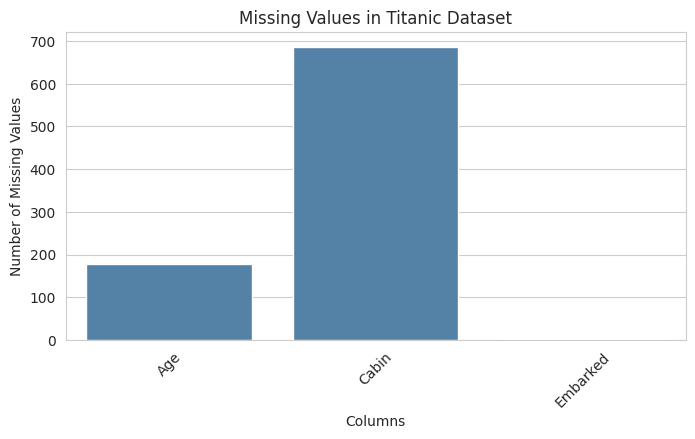

In [5]:
# STEP 4: Visualize missing values

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_values.index, y=missing_values.values, color="steelblue")
plt.title("Missing Values in Titanic Dataset")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

In [6]:
# STEP 5: Check categorical values before cleaning

print("Sex values:")
print(df["Sex"].value_counts(dropna=False))

print("\nEmbarked values:")
print(df["Embarked"].value_counts(dropna=False))

print("\nPassenger class values:")
print(df["Pclass"].value_counts().sort_index())

Sex values:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked values:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

Passenger class values:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [7]:
# STEP 6: Standardize categorical text columns

for col in ["Sex", "Embarked"]:
    df[col] = df[col].astype("string").str.strip().str.title()

print("Text values standardized successfully.")

Text values standardized successfully.


In [8]:
# STEP 7: Handle missing values

# Fill missing Age values using median age based on passenger class
df["Age"] = df.groupby("Pclass")["Age"].transform(
    lambda x: x.fillna(x.median())
)

# Create Deck feature from Cabin
# U means Unknown cabin/deck
df["Deck"] = df["Cabin"].fillna("U").str[0]

# Drop original Cabin column because it has too many missing values
df.drop(columns="Cabin", inplace=True)

# Fill missing Embarked values with the most common port
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after cleaning:
Series([], dtype: int64)


In [9]:
# STEP 8: Check duplicate and invalid values

print("Duplicate rows:", df.duplicated().sum())

# Check invalid values
print("\nMinimum Age:", df["Age"].min())
print("Minimum Fare:", df["Fare"].min())

# Keep only valid values
df = df[(df["Age"] >= 0) & (df["Fare"] >= 0)]

print("\nDataset shape after validity check:", df.shape)

Duplicate rows: 0

Minimum Age: 0.42
Minimum Fare: 0.0

Dataset shape after validity check: (891, 12)


In [10]:
# STEP 9: Detect outliers using IQR method

def find_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = series[(series < lower_limit) | (series > upper_limit)]

    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Number of Outliers:", len(outliers))

print("Age Outliers:")
find_outliers(df["Age"])

print("\nFare Outliers:")
find_outliers(df["Fare"])

Age Outliers:
Lower Limit: -0.5
Upper Limit: 59.5
Number of Outliers: 26

Fare Outliers:
Lower Limit: -26.724
Upper Limit: 65.6344
Number of Outliers: 116


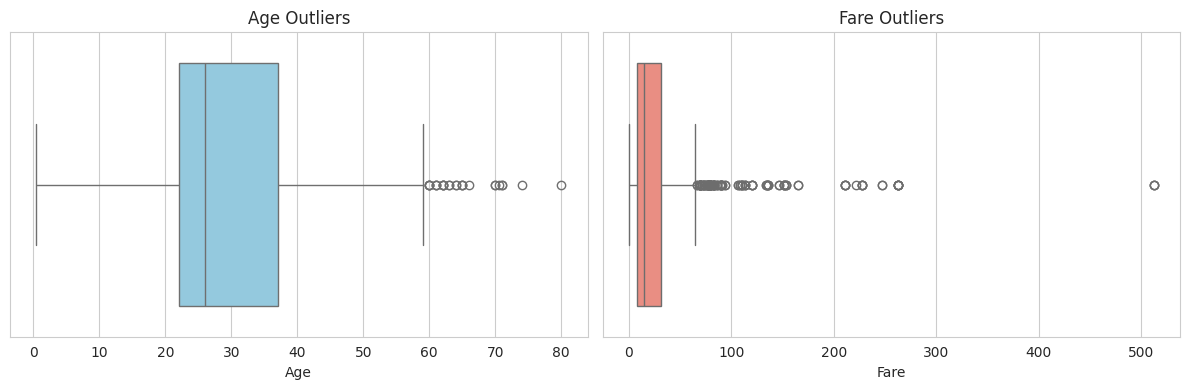

In [11]:
# STEP 10: Visualize outliers using boxplots

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["Age"], color="skyblue")
plt.title("Age Outliers")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["Fare"], color="salmon")
plt.title("Fare Outliers")

plt.tight_layout()
plt.show()

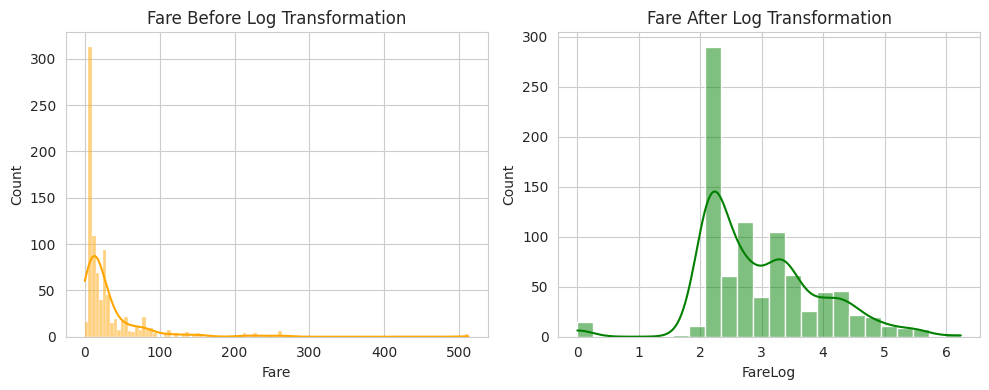

In [12]:
# STEP 11: Log transform Fare
# Fare values are valid but right-skewed, so we reduce skewness.

df["FareLog"] = np.log1p(df["Fare"])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["Fare"], kde=True, color="orange")
plt.title("Fare Before Log Transformation")

plt.subplot(1, 2, 2)
sns.histplot(df["FareLog"], kde=True, color="green")
plt.title("Fare After Log Transformation")

plt.tight_layout()
plt.show()

In [13]:
# STEP 12: Feature engineering

# Extract title from passenger name
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.", expand=False)

# Standardize similar titles
df["Title"] = df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

# Combine uncommon titles into Rare
common_titles = ["Mr", "Miss", "Mrs", "Master"]
df["Title"] = df["Title"].where(df["Title"].isin(common_titles), "Rare")

# Create family size feature
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Create alone/not alone feature
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print("Feature engineering completed.")
df.head()

Feature engineering completed.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,FareLog,Title,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,S,U,2.110213,Mr,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.2833,C,C,4.280593,Mrs,2,0
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.9250,S,U,2.188856,Miss,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.1000,S,C,3.990834,Mrs,2,0
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,S,U,2.202765,Mr,1,1


In [14]:
# STEP 13: Drop unnecessary columns

df.drop(columns=["Name", "Ticket", "PassengerId"], inplace=True)

print("Columns after preprocessing:")
print(df.columns)

Columns after preprocessing:
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Deck', 'FareLog', 'Title', 'FamilySize', 'IsAlone'],
      dtype='object')


In [15]:
# STEP 14: Encoding and scaling preparation

X = df.drop(columns="Survived")
y = df["Survived"]

numeric_features = [
    "Age", "SibSp", "Parch",
    "FareLog", "FamilySize", "IsAlone"
]

categorical_features = [
    "Pclass", "Sex", "Embarked",
    "Deck", "Title"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_ready = preprocessor.fit_transform(X)

print("Preprocessing completed successfully.")
print("Final processed feature matrix shape:", X_ready.shape)

Preprocessing completed successfully.
Final processed feature matrix shape: (891, 28)


In [16]:
# STEP 15: Final dataset inspection

print("Final cleaned dataset shape:", df.shape)

print("\nFinal missing values:")
print(df.isnull().sum())

display(df.head())

Final cleaned dataset shape: (891, 13)

Final missing values:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Deck          0
FareLog       0
Title         0
FamilySize    0
IsAlone       0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,FareLog,Title,FamilySize,IsAlone
0,0,3,Male,22.0,1,0,7.2500,S,U,2.110213,Mr,2,0
1,1,1,Female,38.0,1,0,71.2833,C,C,4.280593,Mrs,2,0
2,1,3,Female,26.0,0,0,7.9250,S,U,2.188856,Miss,1,1
3,1,1,Female,35.0,1,0,53.1000,S,C,3.990834,Mrs,2,0
4,0,3,Male,35.0,0,0,8.0500,S,U,2.202765,Mr,1,1


In [17]:
# STEP 16: Save cleaned dataset

df.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved as titanic_cleaned.csv")

# Download cleaned file if needed
files.download("titanic_cleaned.csv")

Cleaned dataset saved as titanic_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>